# Real-Time ASL Alphabet Recognition — Full Pipeline
### Preprocessing → Model Training → Evaluation

**Dataset:** 29-class ASL dataset (~223K images)  
**GPU:** RTX 5050 (8 GB VRAM)  
**Framework:** PyTorch + torchvision

---
**Pipeline Overview:**
1. Preprocessing & DataLoaders
2. Model Architecture (EfficientNet-B0 fine-tuned)
3. Training loop with mixed-precision (fits comfortably in 8 GB)
4. Evaluation — accuracy, confusion matrix, per-class report
5. Export for real-time inference

## 1. Imports & Environment Check

In [1]:
import os
import json
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.amp import GradScaler, autocast  # mixed-precision for 8 GB VRAM

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    top_k_accuracy_score
)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  # set True after tuning for speed

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device : {DEVICE}")

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU          : {gpu.name}")
    print(f"VRAM         : {gpu.total_memory / 1e9:.1f} GB")
else:
    print("WARNING: CUDA not available — training will be slow on CPU!")

Using device : cuda
GPU          : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM         : 8.5 GB


## 2. Configuration

All hyper-parameters and paths are centralised here — change once, affects everything.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("../data_2/raw/train")   # folder with one sub-folder per class
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Image settings ────────────────────────────────────────────────────────────
# EDA showed dominant shape is 480×640; EfficientNet-B0 expects 224×224.
# Grayscale → convert to 3-channel so pretrained weights still apply.
IMG_SIZE   = 224      # EfficientNet input size
GRAYSCALE  = True     # convert to grayscale then stack to 3ch (saves VRAM)

# ── Training settings ─────────────────────────────────────────────────────────
NUM_CLASSES   = 29    # A-Z (26) + space + del + nothing
BATCH_SIZE    = 128    # fits in 8 GB VRAM with mixed-precision; reduce to 32 if OOM
NUM_EPOCHS    = 30
LR            = 1e-3  # initial LR for classifier head
LR_BACKBONE   = 1e-4  # smaller LR for pretrained backbone layers
WEIGHT_DECAY  = 1e-4
VAL_SPLIT     = 0.15  # 15% of data for validation
NUM_WORKERS   = 4     # adjust to your CPU core count

# ── Mixed-precision (AMP) ─────────────────────────────────────────────────────
USE_AMP = True        # halves VRAM usage, ~1.5–2× faster on Ampere / Ada GPUs

print("Configuration loaded ✓")
print(f"  Data dir   : {DATA_DIR}")
print(f"  Image size : {IMG_SIZE}×{IMG_SIZE}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  AMP        : {USE_AMP}")

Configuration loaded ✓
  Data dir   : ..\data_2\raw\train
  Image size : 224×224
  Batch size : 128
  Epochs     : 30
  AMP        : True


## 3. Preprocessing & Data Augmentation

### Why these transforms?

| Transform | Reason |
|---|---|
| `Resize(224)` | EfficientNet-B0 expects 224×224 input |
| Grayscale → 3-ch | ASL hand shapes are luminance-driven; grayscale reduces noise. We still need 3 channels because the backbone's first conv was pretrained on RGB. |
| `RandomHorizontalFlip` | Real cameras may mirror the hand |
| `RandomRotation(±15°)` | Slight wrist rotation in real use |
| `ColorJitter` | Lighting variation across environments |
| `RandomAffine` | Minor translation/scale to simulate camera position shift |
| `Normalize(ImageNet stats)` | Required when loading pretrained EfficientNet weights |

In [3]:
# ImageNet mean/std — used because we load pretrained ImageNet weights
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Helper: grayscale-then-replicate to 3 channels ────────────────────────────
class GrayscaleTo3Channel:
    """Convert image to grayscale, then replicate across R, G, B channels.
    
    This preserves pretrained RGB weight compatibility while removing
    colour information that does not help with hand-shape classification.
    """
    def __call__(self, img):
        gray = transforms.functional.to_grayscale(img, num_output_channels=3)
        return gray


# ── Training transform: aggressive augmentation ───────────────────────────────
train_transform = transforms.Compose([
    GrayscaleTo3Channel(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),   # up to 10% shift
        scale=(0.85, 1.15),     # zoom in/out
    ),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.1,
    ),
    transforms.ToTensor(),           # converts PIL → [0,1] float32 tensor
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  # simulate occlusion
])

# ── Validation/test transform: no augmentation, only normalise ────────────────
val_transform = transforms.Compose([
    GrayscaleTo3Channel(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined ✓")

Transforms defined ✓


## 4. Dataset Loading & Train/Validation Split

We use `ImageFolder` which auto-assigns integer labels from sub-folder names. Then we split indices 85/15 train/val.

In [4]:
from torch.utils.data import Subset

# ── Load full dataset with training transforms first (we'll override for val) ──
full_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=train_transform)

# Class info
class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Total images : {len(full_dataset)}")
print(f"Classes ({num_classes}): {class_names}")

# ── Stratified split ──────────────────────────────────────────────────────────
# Group indices by class so we split proportionally
from collections import defaultdict

class_to_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_dataset.samples):
    class_to_indices[label].append(idx)

train_indices, val_indices = [], []
for label, indices in class_to_indices.items():
    random.shuffle(indices)
    split = int(len(indices) * (1 - VAL_SPLIT))
    train_indices.extend(indices[:split])
    val_indices.extend(indices[split:])

random.shuffle(train_indices)
random.shuffle(val_indices)

print(f"\nTrain samples: {len(train_indices)}")
print(f"Val samples  : {len(val_indices)}")

# ── Build Subset datasets with correct transforms ─────────────────────────────
# Training subset keeps the augmented transform
train_dataset = Subset(full_dataset, train_indices)

# Validation subset uses clean transform — we create a separate ImageFolder for this
val_dataset_base = datasets.ImageFolder(root=str(DATA_DIR), transform=val_transform)
val_dataset = Subset(val_dataset_base, val_indices)

Total images : 223074
Classes (29): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']

Train samples: 189600
Val samples  : 33474


## 5. Handling Class Imbalance with WeightedRandomSampler

The EDA shows `nothing` has only ~3,030 images while `A` has ~8,458.  
Without correction the model will bias toward majority classes.  
`WeightedRandomSampler` over-samples rare classes so every class appears equally often per epoch.

In [6]:
import os, platform

# ── Fix 1: extract labels correctly (no disk rescan) ──────────────────────────
train_labels_arr = np.array([full_dataset.samples[i][1] for i in train_indices])
class_counts_arr  = np.bincount(train_labels_arr, minlength=NUM_CLASSES)
weights_per_class = len(train_labels_arr) / np.maximum(class_counts_arr, 1)
sample_weights    = weights_per_class[train_labels_arr]

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(train_indices),
    replacement=True
)

# ── Fix 2: safe num_workers for your OS ───────────────────────────────────────
# On Windows, DataLoader forking is broken inside Jupyter unless
# the dataset is inside  if __name__ == '__main__':  — which notebooks can't do.
# Solution: use num_workers=0 (loads in main process, no forking).
# On Linux/macOS this is not a problem — use 4.
if platform.system() == "Windows":
    SAFE_WORKERS = 0   # forking broken in Jupyter on Windows
    print("Windows detected — using num_workers=0 to avoid deadlock")
else:
    SAFE_WORKERS = NUM_WORKERS

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=SAFE_WORKERS,
    pin_memory=SAFE_WORKERS > 0,       # pin_memory only useful with workers
    persistent_workers=SAFE_WORKERS > 0,
    prefetch_factor=2 if SAFE_WORKERS > 0 else None,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=SAFE_WORKERS,
    pin_memory=SAFE_WORKERS > 0,
    persistent_workers=SAFE_WORKERS > 0,
    prefetch_factor=2 if SAFE_WORKERS > 0 else None,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

# ── Sanity check ──────────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch shape   : {images.shape}")
print(f"Labels        : {[class_names[l] for l in labels[:8].tolist()]}")

Windows detected — using num_workers=0 to avoid deadlock
Train batches : 1482
Val batches   : 262
Batch shape   : torch.Size([128, 3, 224, 224])
Labels        : ['R', 'H', 'F', 'J', 'J', 'V', 'X', 'I']


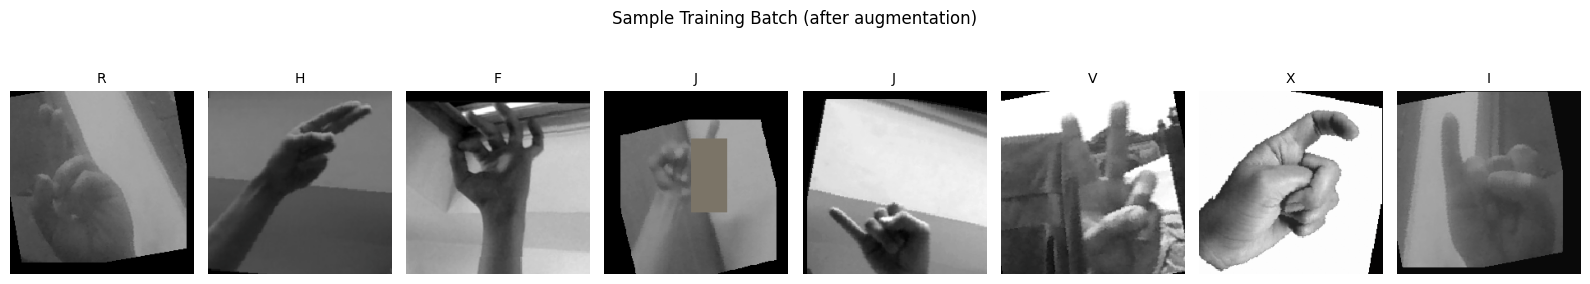

In [8]:
# ── Visualise a sample batch ──────────────────────────────────────────────────
def imshow_batch(images, labels, class_names, n=8):
    """Un-normalise and display n images from a batch."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    imgs = images[:n] * std + mean   # reverse normalisation
    imgs = imgs.clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(2 * n, 3))
    for i, ax in enumerate(axes):
        # Grayscale images — take channel 0 for display
        ax.imshow(imgs[i].permute(1, 2, 0).numpy())
        ax.set_title(class_names[labels[i]], fontsize=10)
        ax.axis("off")
    plt.suptitle("Sample Training Batch (after augmentation)", y=1.02)
    plt.tight_layout()
    plt.show()

imshow_batch(images, labels, class_names)

## 6. Class Distribution Visualisation

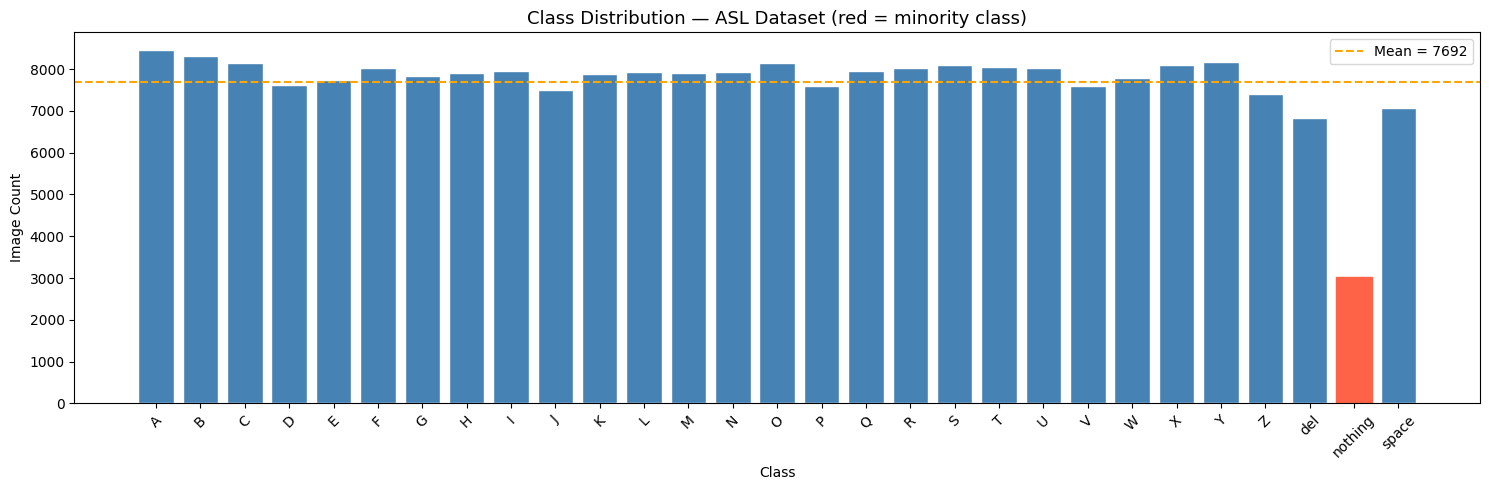

Imbalance ratio (max/min): 2.79x
WeightedRandomSampler will correct this during training.


In [9]:
# Overall class distribution (full dataset)
all_labels = [label for _, label in full_dataset.samples]
dist = Counter(all_labels)

names  = [class_names[k] for k in sorted(dist)]
counts = [dist[k] for k in sorted(dist)]

plt.figure(figsize=(15, 5))
bars = plt.bar(names, counts, color="steelblue", edgecolor="white")

# Highlight the minority class
min_idx = counts.index(min(counts))
bars[min_idx].set_color("tomato")

plt.axhline(np.mean(counts), color="orange", linestyle="--", label=f"Mean = {np.mean(counts):.0f}")
plt.title("Class Distribution — ASL Dataset (red = minority class)", fontsize=13)
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=150)
plt.show()

imbalance_ratio = max(counts) / min(counts)
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}x")
print(f"WeightedRandomSampler will correct this during training.")

## 7. Model Architecture — EfficientNet-B0 (Transfer Learning)

### Why EfficientNet-B0?
- **Accuracy vs. size**: State-of-the-art accuracy at a small footprint (~5 M parameters)
- **VRAM friendly**: Full fine-tuning fits in ~4 GB at batch=64 with AMP → safe for your 8 GB RTX 5050
- **Speed**: ~40ms per batch inference → fast enough for real-time (~25 fps)

### Strategy: Two-phase fine-tuning
1. **Phase 1 (epochs 1-10)**: Freeze backbone, only train the new classifier head → fast convergence
2. **Phase 2 (epochs 11-30)**: Unfreeze all layers with a lower LR → fine-tune the entire network

In [10]:
def build_model(num_classes: int, pretrained: bool = True) -> nn.Module:
    """Build EfficientNet-B0 with a custom classification head."""
    weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b0(weights=weights)

    # Replace the default 1000-class classifier with our custom head
    in_features = model.classifier[1].in_features  # 1280 for B0
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes),
    )
    return model


def freeze_backbone(model: nn.Module) -> None:
    """Freeze all layers except the classifier head."""
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False


def unfreeze_all(model: nn.Module) -> None:
    """Unfreeze all parameters for full fine-tuning."""
    for param in model.parameters():
        param.requires_grad = True


# Build and move to GPU
model = build_model(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(DEVICE)

# Count parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_all   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_all:,}")

Total parameters     : 4,678,297
Trainable parameters : 4,678,297


## 8. Loss, Optimiser & Scheduler

- **Loss**: Cross-entropy with `label_smoothing=0.1` — prevents overconfident predictions on ambiguous signs
- **Optimiser**: AdamW — Adam with proper weight decay (better generalisation)
- **Scheduler**: `OneCycleLR` — starts slow, ramps up, then anneals; great for transfer learning

In [11]:
def make_optimizer_and_scheduler(model, phase: int, steps_per_epoch: int, epochs: int):
    """Create optimizer with different LRs for backbone vs classifier."""
    
    backbone_params   = [p for n, p in model.named_parameters() if "classifier" not in n and p.requires_grad]
    classifier_params = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]

    if phase == 1:
        # Phase 1: only classifier is unfrozen
        param_groups = [{"params": classifier_params, "lr": LR}]
    else:
        # Phase 2: backbone gets smaller LR, classifier keeps normal LR
        param_groups = [
            {"params": backbone_params,   "lr": LR_BACKBONE},
            {"params": classifier_params, "lr": LR},
        ]

    optimizer = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[g["lr"] for g in param_groups],
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        pct_start=0.3,       # 30% of training is warmup
        anneal_strategy="cos",
    )
    return optimizer, scheduler


# Label-smoothed cross-entropy
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print("Loss function: CrossEntropyLoss (label_smoothing=0.1)")
print("Optimiser    : AdamW")
print("Scheduler    : OneCycleLR")

Loss function: CrossEntropyLoss (label_smoothing=0.1)
Optimiser    : AdamW
Scheduler    : OneCycleLR


## 9. Training & Validation Functions

Mixed-precision (`autocast`) halves VRAM usage and speeds up training on your RTX 5050.

In [13]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, scheduler, criterion, scaler, device, epoch, num_epochs):
    """
    Run one full training epoch.
    
    - Mixed precision (autocast) halves VRAM usage on RTX 5050
    - Gradient clipping prevents exploding gradients during phase 2
    - Progress bar shows live loss, accuracy and learning rate per batch
    
    Returns: (avg_loss, top1_accuracy) as floats
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(
        loader,
        desc=f"  Epoch {epoch:02d}/{num_epochs} [Train]",
        unit="batch",
        colour="green",
        leave=False,
        dynamic_ncols=True,
    )

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Zero gradients (set_to_none=True is faster than zero_grad())
        optimizer.zero_grad(set_to_none=True)

        # ── Forward pass (mixed precision) ────────────────────────────────────
        with autocast('cuda', enabled=USE_AMP):
            outputs = model(images)          # shape: (B, num_classes)
            loss    = criterion(outputs, labels)

        # ── Backward pass (scaled for AMP) ────────────────────────────────────
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # OneCycleLR steps every BATCH (not every epoch)
        scheduler.step()

        # ── Running metrics ───────────────────────────────────────────────────
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(dim=1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

        pbar.set_postfix({
            "loss": f"{total_loss / total:.4f}",
            "acc" : f"{correct / total * 100:.2f}%",
            "lr"  : f"{scheduler.get_last_lr()[0]:.2e}",
        })

    pbar.close()
    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device, epoch, num_epochs):
    """
    Run one full validation epoch.
    
    - @torch.no_grad() disables gradient tracking entirely (saves memory + speed)
    - No augmentation is applied (val_transform is clean resize + normalise only)
    - Progress bar shows live loss and accuracy per batch
    
    Returns: (avg_loss, top1_accuracy) as floats
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(
        loader,
        desc=f"  Epoch {epoch:02d}/{num_epochs} [Val]  ",
        unit="batch",
        colour="blue",
        leave=False,
        dynamic_ncols=True,
    )

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast('cuda', enabled=USE_AMP):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(dim=1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

        pbar.set_postfix({
            "loss": f"{total_loss / total:.4f}",
            "acc" : f"{correct / total * 100:.2f}%",
        })

    pbar.close()
    return total_loss / total, correct / total


print("Training and validation functions defined ✓")

Training and validation functions defined ✓


## 10. Main Training Loop

- **Epochs 1-5**: Backbone frozen (Phase 1) — trains only the head, very fast
- **Epochs 6-20**: Full fine-tuning (Phase 2) — backbone unlocked with small LR
- **Best model checkpoint** saved whenever validation accuracy improves

In [15]:
# ── Phase 1 setup: freeze backbone, train classifier head only ────────────────
PHASE1_EPOCHS = 10
PHASE2_EPOCHS = NUM_EPOCHS - PHASE1_EPOCHS

freeze_backbone(model)
trainable_phase1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 1 — Trainable parameters: {trainable_phase1:,} (classifier head only)")

optimizer, scheduler = make_optimizer_and_scheduler(
    model, phase=1,
    steps_per_epoch=len(train_loader),
    epochs=PHASE1_EPOCHS
)

# Fixed deprecation: GradScaler now takes device as first argument
scaler = GradScaler('cuda', enabled=USE_AMP)

# ── History tracking ──────────────────────────────────────────────────────────
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "lr":         []
}

best_val_acc    = 0.0
best_model_path = OUTPUT_DIR / "best_model.pth"

print(f"\nStarting training for {NUM_EPOCHS} epochs")
print(f"  Phase 1 : epochs  1 – {PHASE1_EPOCHS}  (classifier head only)")
print(f"  Phase 2 : epochs  {PHASE1_EPOCHS+1} – {NUM_EPOCHS}  (full network)")
print(f"  AMP     : {USE_AMP}")
print(f"  Device  : {DEVICE}\n")

# ── Main training loop ────────────────────────────────────────────────────────
for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Phase transition: unfreeze backbone at epoch PHASE1_EPOCHS + 1 ───────
    if epoch == PHASE1_EPOCHS + 1:
        print("\n" + "═" * 62)
        print("  Switching to Phase 2 — unfreezing full backbone")
        print("═" * 62)
        unfreeze_all(model)
        trainable_phase2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Trainable parameters: {trainable_phase2:,} (all layers)\n")
        optimizer, scheduler = make_optimizer_and_scheduler(
            model, phase=2,
            steps_per_epoch=len(train_loader),
            epochs=PHASE2_EPOCHS
        )

    # ── Train ─────────────────────────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler,
        criterion, scaler, DEVICE, epoch, NUM_EPOCHS
    )

    # ── Validate ──────────────────────────────────────────────────────────────
    val_loss, val_acc = validate(
        model, val_loader, criterion,
        DEVICE, epoch, NUM_EPOCHS
    )

    elapsed     = time.time() - t0
    current_lr  = optimizer.param_groups[0]["lr"]
    is_best     = val_acc > best_val_acc
    phase_label = "Phase 1 — head only" if epoch <= PHASE1_EPOCHS else "Phase 2 — full network"

    # ── Log history ───────────────────────────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    # ── Epoch summary ─────────────────────────────────────────────────────────
    print("\n" + "─" * 62)
    print(f"  Epoch {epoch:02d}/{NUM_EPOCHS}  [{phase_label}]")
    print("─" * 62)
    print(f"  {'Train Loss':<20}: {train_loss:.4f}")
    print(f"  {'Train Accuracy':<20}: {train_acc * 100:.2f}%")
    print(f"  {'Val Loss':<20}: {val_loss:.4f}")
    print(f"  {'Val Accuracy':<20}: {val_acc * 100:.2f}%")
    print(f"  {'Learning Rate':<20}: {current_lr:.2e}")
    print(f"  {'Epoch Time':<20}: {elapsed:.1f}s")
    print(f"  {'Best Val Acc':<20}: {best_val_acc * 100:.2f}%  {'← new best! ✓' if is_best else ''}")
    print("─" * 62)

    # ── Save best checkpoint ──────────────────────────────────────────────────
    if is_best:
        best_val_acc = val_acc
        torch.save({
            "epoch":       epoch,
            "model_state": model.state_dict(),
            "optim_state": optimizer.state_dict(),
            "val_acc":     best_val_acc,
            "class_names": class_names,
            "history":     history,
        }, best_model_path)
        print(f"  ✓ Checkpoint saved → {best_model_path}\n")

# ── Training complete ─────────────────────────────────────────────────────────
print("\n" + "═" * 62)
print("  Training complete")
print("═" * 62)
print(f"  Best Val Accuracy : {best_val_acc * 100:.2f}%")
print(f"  Checkpoint saved  : {best_model_path}")
print("═" * 62)

Phase 1 — Trainable parameters: 670,749 (classifier head only)

Starting training for 30 epochs
  Phase 1 : epochs  1 – 10  (classifier head only)
  Phase 2 : epochs  11 – 30  (full network)
  AMP     : True
  Device  : cuda




──────────────────────────────────────────────────────────────
  Epoch 01/30  [Phase 1 — head only]
──────────────────────────────────────────────────────────────
  Train Loss          : 2.4523
  Train Accuracy      : 43.74%
  Val Loss            : 1.6225
  Val Accuracy        : 70.99%
  Learning Rate       : 2.80e-04
  Epoch Time          : 875.1s
  Best Val Acc        : 0.00%  ← new best! ✓
──────────────────────────────────────────────────────────────
  ✓ Checkpoint saved → outputs\best_model.pth




──────────────────────────────────────────────────────────────
  Epoch 02/30  [Phase 1 — head only]
──────────────────────────────────────────────────────────────
  Train Loss          : 1.7418
  Train Accuracy      : 63.10%
  Val Loss            : 1.3407
  Val Accuracy        : 79.19%
  Learning Rate       : 7.60e-04
  Epoch Time          : 983.1s
  Best Val Acc        : 70.99%  ← new best! ✓
──────────────────────────────────────────────────────────────
  ✓ Checkpoint saved → outputs\best_model.pth




──────────────────────────────────────────────────────────────
  Epoch 03/30  [Phase 1 — head only]
──────────────────────────────────────────────────────────────
  Train Loss          : 1.5668
  Train Accuracy      : 69.24%
  Val Loss            : 1.1997
  Val Accuracy        : 84.20%
  Learning Rate       : 1.00e-03
  Epoch Time          : 929.5s
  Best Val Acc        : 79.19%  ← new best! ✓
──────────────────────────────────────────────────────────────
  ✓ Checkpoint saved → outputs\best_model.pth




──────────────────────────────────────────────────────────────
  Epoch 04/30  [Phase 1 — head only]
──────────────────────────────────────────────────────────────
  Train Loss          : 1.4718
  Train Accuracy      : 72.93%
  Val Loss            : 1.1265
  Val Accuracy        : 87.75%
  Learning Rate       : 9.50e-04
  Epoch Time          : 892.1s
  Best Val Acc        : 84.20%  ← new best! ✓
──────────────────────────────────────────────────────────────
  ✓ Checkpoint saved → outputs\best_model.pth



...


──────────────────────────────────────────────────────────────
  Epoch 27/30  [Phase 2 — full network]
──────────────────────────────────────────────────────────────
  Train Loss          : 0.6521
  Train Accuracy      : 99.91%
  Val Loss            : 0.6413
  Val Accuracy        : 99.96%
  Learning Rate       : 1.09e-05
  Epoch Time          : 1019.1s
  Best Val Acc        : 99.96%  
──────────────────────────────────────────────────────────────



──────────────────────────────────────────────────────────────
  Epoch 28/30  [Phase 2 — full network]
──────────────────────────────────────────────────────────────
  Train Loss          : 0.6514
  Train Accuracy      : 99.92%
  Val Loss            : 0.6410
  Val Accuracy        : 99.96%
  Learning Rate       : 4.95e-06
  Epoch Time          : 1019.9s
  Best Val Acc        : 99.96%  
──────────────────────────────────────────────────────────────



──────────────────────────────────────────────────────────────
  Epoch 29/30  [Phase 2 — full network]
──────────────────────────────────────────────────────────────
  Train Loss          : 0.6513
  Train Accuracy      : 99.92%
  Val Loss            : 0.6409
  Val Accuracy        : 99.96%
  Learning Rate       : 1.25e-06
  Epoch Time          : 1020.3s
  Best Val Acc        : 99.96%  
──────────────────────────────────────────────────────────────


                                                                                                    c=99.96%]      4.01e-10]


──────────────────────────────────────────────────────────────
  Epoch 30/30  [Phase 2 — full network]
──────────────────────────────────────────────────────────────
  Train Loss          : 0.6510
  Train Accuracy      : 99.93%
  Val Loss            : 0.6409
  Val Accuracy        : 99.96%
  Learning Rate       : 4.01e-10
  Epoch Time          : 1043.1s
  Best Val Acc        : 99.96%  
──────────────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════
  Training complete
══════════════════════════════════════════════════════════════
  Best Val Accuracy : 99.96%
  Checkpoint saved  : outputs\best_model.pth
══════════════════════════════════════════════════════════════


## 11. Training Curves

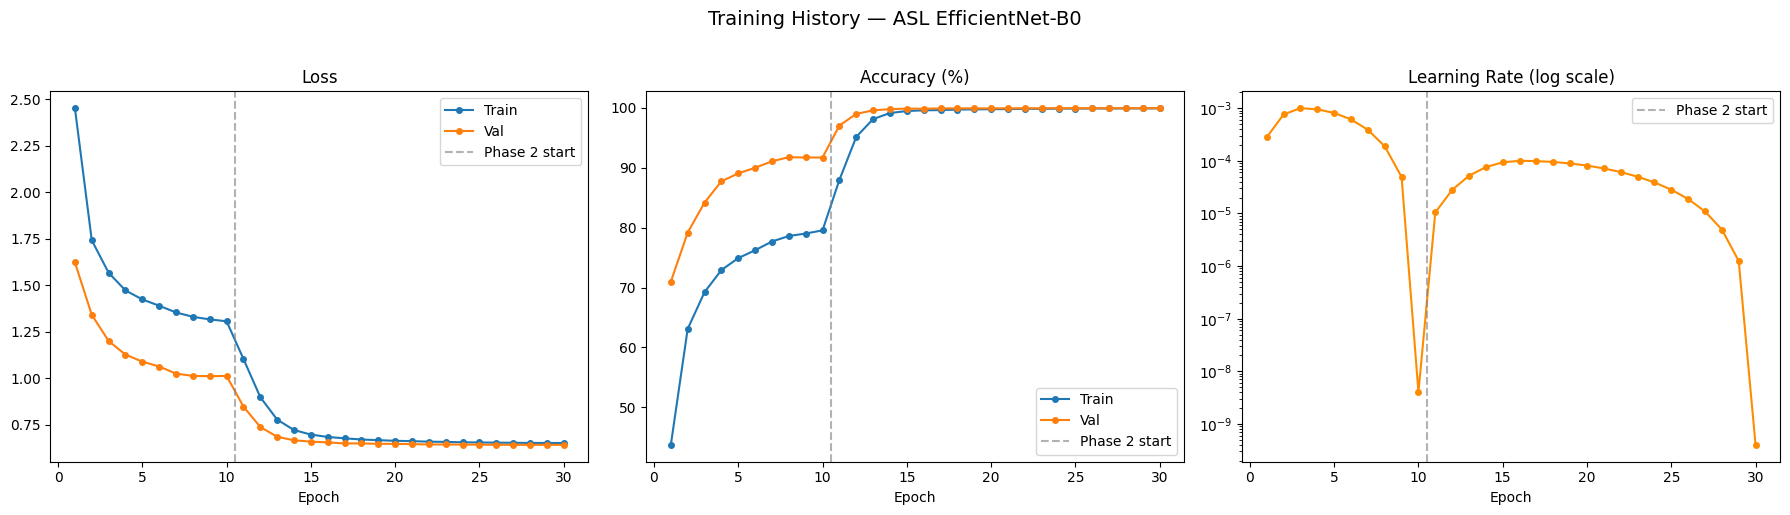

In [16]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train", marker="o", markersize=4)
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   marker="o", markersize=4)
axes[0].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle="--", alpha=0.6, label="Phase 2 start")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in history["train_acc"]], label="Train", marker="o", markersize=4)
axes[1].plot(epochs_range, [a*100 for a in history["val_acc"]],   label="Val",   marker="o", markersize=4)
axes[1].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle="--", alpha=0.6, label="Phase 2 start")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# Learning rate
axes[2].semilogy(epochs_range, history["lr"], color="darkorange", marker="o", markersize=4)
axes[2].axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle="--", alpha=0.6, label="Phase 2 start")
axes[2].set_title("Learning Rate (log scale)")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("Training History — ASL EfficientNet-B0", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Evaluation on Validation Set

Load the best checkpoint and compute:
- Top-1 and Top-5 accuracy
- Per-class precision, recall, F1
- Confusion matrix

In [18]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_acc={checkpoint['val_acc']*100:.2f}%)")


# ── Collect all predictions ───────────────────────────────────────────────────
@torch.no_grad()
def get_predictions(model, loader, device):
    """Return (all_true_labels, all_pred_labels, all_logits)."""
    model.eval()
    all_true, all_pred, all_logits = [], [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        with autocast('cuda', enabled=USE_AMP):
            logits = model(images)
        preds = logits.argmax(dim=1).cpu()
        all_true.append(labels)
        all_pred.append(preds)
        all_logits.append(logits.cpu())

    return (
        torch.cat(all_true).numpy(),
        torch.cat(all_pred).numpy(),
        torch.cat(all_logits).numpy()
    )


y_true, y_pred, y_logits = get_predictions(model, val_loader, DEVICE)

# ── Accuracy metrics ──────────────────────────────────────────────────────────
top1 = accuracy_score(y_true, y_pred)
top5 = top_k_accuracy_score(y_true, y_logits, k=5, labels=list(range(NUM_CLASSES)))

print(f"\n{'='*40}")
print(f"  Top-1 Accuracy : {top1*100:.2f}%")
print(f"  Top-5 Accuracy : {top5*100:.2f}%")
print(f"{'='*40}")

Loaded best model from epoch 24 (val_acc=99.96%)

  Top-1 Accuracy : 99.96%
  Top-5 Accuracy : 99.99%


In [19]:
# ── Per-class classification report ──────────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=class_names, digits=3)
print("Per-Class Classification Report:")
print(report)

# Save report to file
with open(OUTPUT_DIR / "classification_report.txt", "w") as f:
    f.write(report)
print("Report saved to outputs/classification_report.txt")

Per-Class Classification Report:
              precision    recall  f1-score   support

           A      1.000     1.000     1.000      1269
           B      0.999     1.000     1.000      1247
           C      1.000     1.000     1.000      1222
           D      1.000     1.000     1.000      1145
           E      0.997     1.000     0.998      1162
           F      1.000     0.999     1.000      1205
           G      1.000     1.000     1.000      1177
           H      1.000     1.000     1.000      1186
           I      1.000     1.000     1.000      1193
           J      0.999     1.000     1.000      1126
           K      1.000     1.000     1.000      1182
           L      1.000     1.000     1.000      1191
           M      0.999     0.999     0.999      1185
           N      1.000     0.999     1.000      1190
           O      1.000     1.000     1.000      1221
           P      1.000     1.000     1.000      1141
           Q      1.000     1.000     1.000     

## 13. Confusion Matrix

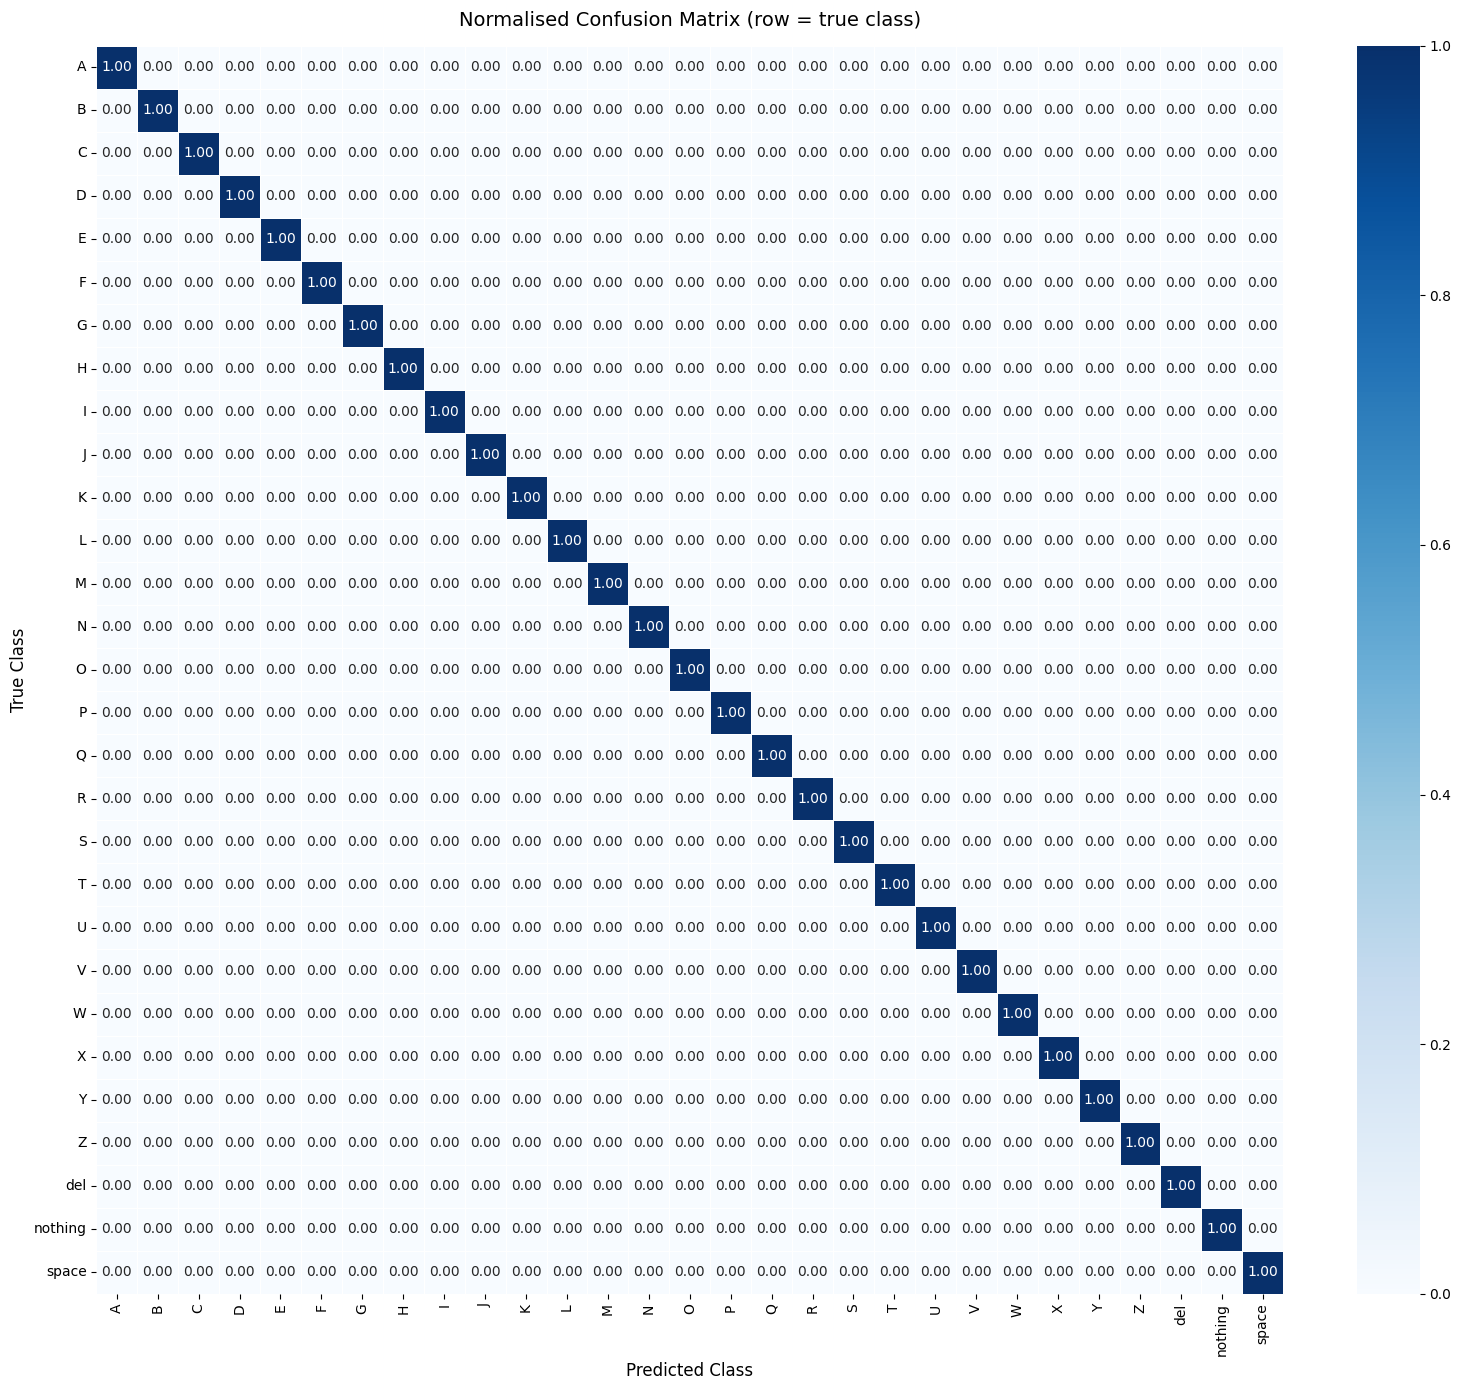


Most confused class pairs (true → predicted):


In [20]:
cm = confusion_matrix(y_true, y_pred)

# Normalise by row (true class) for readability
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Normalised Confusion Matrix (row = true class)", fontsize=14, pad=15)
ax.set_xlabel("Predicted Class", fontsize=12)
ax.set_ylabel("True Class", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Identify the most confused pairs ─────────────────────────────────────────
print("\nMost confused class pairs (true → predicted):")
# Zero the diagonal (correct predictions)
cm_no_diag = cm_norm.copy()
np.fill_diagonal(cm_no_diag, 0)

top_errors = np.dstack(np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1], cm_no_diag.shape))[0][:10]
for true_idx, pred_idx in top_errors:
    rate = cm_no_diag[true_idx, pred_idx]
    if rate > 0.01:
        print(f"  {class_names[true_idx]:>8} → {class_names[pred_idx]:<8}  ({rate*100:.1f}% of true samples misclassified)")

## 14. Per-Class Accuracy Bar Chart

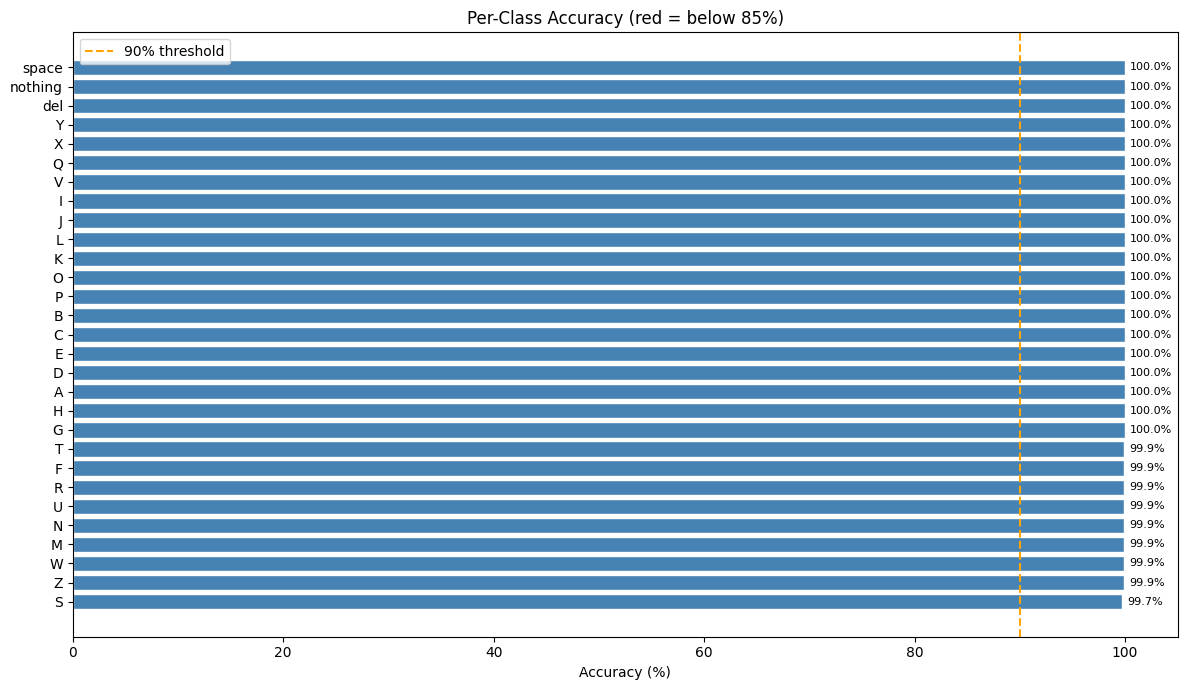

In [21]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# Sort by accuracy for easy reading
sorted_indices = np.argsort(per_class_acc)
sorted_names   = [class_names[i] for i in sorted_indices]
sorted_accs    = per_class_acc[sorted_indices]

colors = ["tomato" if a < 0.85 else "steelblue" for a in sorted_accs]

plt.figure(figsize=(12, 7))
bars = plt.barh(sorted_names, sorted_accs * 100, color=colors, edgecolor="white")
plt.axvline(90, color="orange", linestyle="--", label="90% threshold")
plt.xlabel("Accuracy (%)")
plt.title("Per-Class Accuracy (red = below 85%)")
plt.legend()
plt.xlim(0, 105)

# Add value labels
for bar, acc in zip(bars, sorted_accs):
    plt.text(acc * 100 + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{acc*100:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Visualise Prediction Errors

Shows samples where the model was wrong — very useful for understanding failure modes.

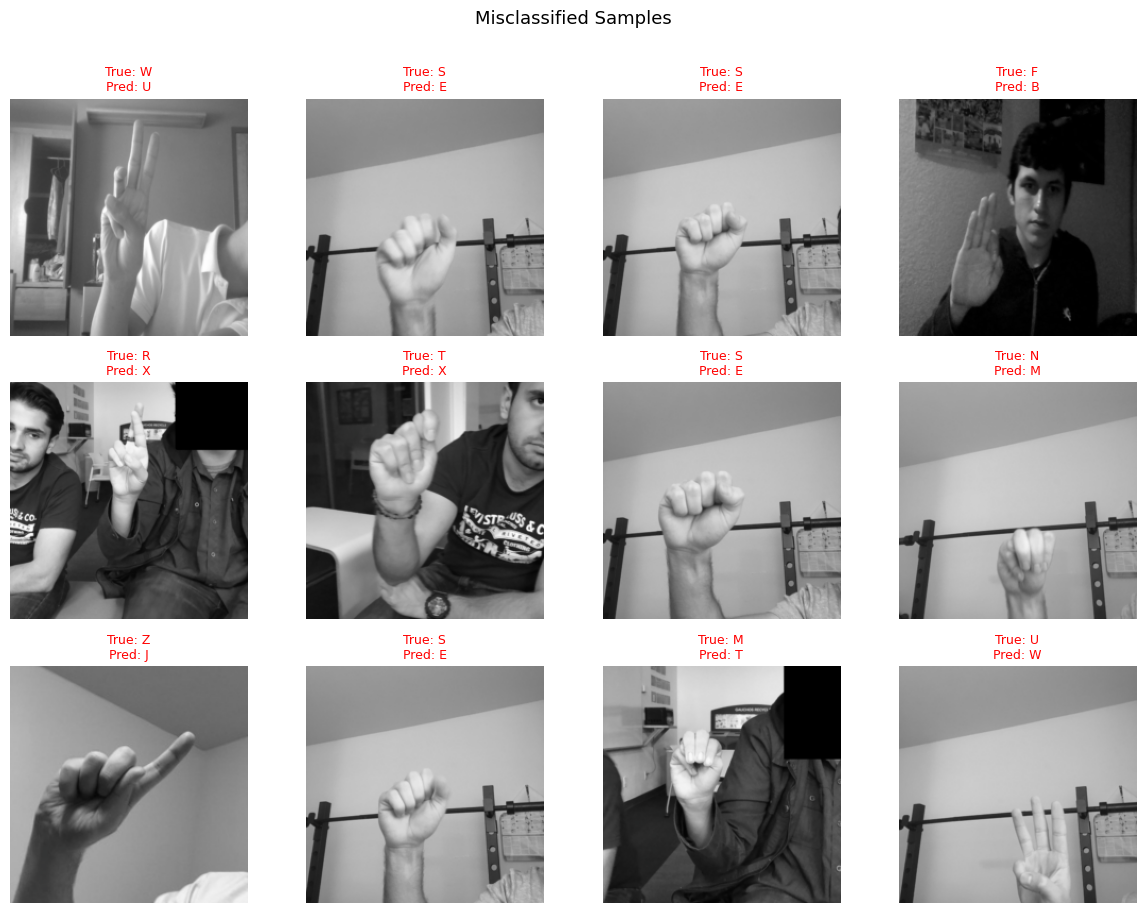

In [23]:
@torch.no_grad()
def show_errors(model, loader, class_names, device, n=16):
    """Display n misclassified images with true and predicted labels."""
    model.eval()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    error_imgs, error_true, error_pred = [], [], []

    for images, labels in loader:
        if len(error_imgs) >= n:
            break
        images_gpu = images.to(device, non_blocking=True)
        with autocast('cuda', enabled=USE_AMP):
            preds = model(images_gpu).argmax(dim=1).cpu()

        wrong_mask = preds != labels
        for i in range(len(labels)):
            if wrong_mask[i] and len(error_imgs) < n:
                img_unnorm = (images[i] * std + mean).clamp(0, 1)
                error_imgs.append(img_unnorm)
                error_true.append(labels[i].item())
                error_pred.append(preds[i].item())

    cols = 4
    rows = (len(error_imgs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()

    for i, (img, true, pred) in enumerate(zip(error_imgs, error_true, error_pred)):
        axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}",
                          fontsize=9, color="red")
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Misclassified Samples", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "error_samples.png", dpi=150, bbox_inches="tight")
    plt.show()


show_errors(model, val_loader, class_names, DEVICE, n=16)

## 16. Export for Real-Time Inference

We export two formats:
1. **PyTorch `.pth` checkpoint** — for continued training
2. **TorchScript `.pt`** — for deployment in OpenCV/real-time pipeline without needing class definitions

We also apply `temporal_smoothing` (moving average over last N frames) as noted in the EDA report — this prevents flickering predictions in real-time use.

In [24]:
# ── TorchScript export ────────────────────────────────────────────────────────
model.eval()
example_input = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

scripted_model = torch.jit.trace(model, example_input)
script_path = OUTPUT_DIR / "asl_model_scripted.pt"
scripted_model.save(str(script_path))
print(f"TorchScript model saved → {script_path}")

# ── Save class names mapping ──────────────────────────────────────────────────
class_map = {i: name for i, name in enumerate(class_names)}
with open(OUTPUT_DIR / "class_names.json", "w") as f:
    json.dump(class_map, f, indent=2)
print(f"Class map saved → {OUTPUT_DIR / 'class_names.json'}")

TorchScript model saved → outputs\asl_model_scripted.pt
Class map saved → outputs\class_names.json


In [25]:
# ── Temporal Smoother for real-time use ───────────────────────────────────────
# As flagged in the EDA report: temporal_smoothing_required = True
# This class averages predictions over a sliding window of frames,
# which prevents flickering when the hand is between gestures.

from collections import deque

class TemporalSmoother:
    """Moving-average smoother over the last `window` frame predictions.
    
    Usage in real-time loop:
        smoother = TemporalSmoother(window=7)
        pred_label = smoother.update(logits)  # call once per frame
    """
    def __init__(self, num_classes: int, window: int = 7):
        self.window      = window
        self.num_classes = num_classes
        self.buffer      = deque(maxlen=window)   # stores softmax vectors

    def update(self, logits: torch.Tensor) -> int:
        """Accept raw logits (1D or 2D with batch=1). Return smoothed class index."""
        probs = torch.softmax(logits.squeeze(0).cpu(), dim=-1).numpy()
        self.buffer.append(probs)

        avg_probs = np.mean(list(self.buffer), axis=0)  # average over window
        return int(np.argmax(avg_probs))

    def reset(self):
        self.buffer.clear()


# ── Demo: simulate a real-time inference call ─────────────────────────────────
smoother = TemporalSmoother(num_classes=NUM_CLASSES, window=7)

# Simulate 10 frames
model.eval()
with torch.no_grad():
    sample_img, sample_lbl = next(iter(val_loader))
    frame = sample_img[0:1].to(DEVICE)  # one image
    for _ in range(10):
        logits = model(frame)
        pred_idx = smoother.update(logits)

print(f"True class     : {class_names[sample_lbl[0].item()]}")
print(f"Smoothed pred  : {class_names[pred_idx]}")
print("TemporalSmoother working correctly ✓")

True class     : Q
Smoothed pred  : Q
TemporalSmoother working correctly ✓


## 17. Final Summary

In [27]:
print("="*55)
print("  ASL RECOGNITION PIPELINE — SUMMARY")
print("="*55)
print(f"  Model        : EfficientNet-B0 (pretrained ImageNet)")
print(f"  Classes      : {NUM_CLASSES}")
print(f"  Image size   : {IMG_SIZE}×{IMG_SIZE} px (grayscale→3ch)")
print(f"  Batch size   : {BATCH_SIZE} (AMP enabled)")
print(f"  Epochs       : {NUM_EPOCHS} (Phase1={PHASE1_EPOCHS}, Phase2={PHASE2_EPOCHS})")
print(f"  Best Val Acc : {best_val_acc*100:.2f}%")
print(f"  Top-1 Acc    : {top1*100:.2f}%")
print(f"  Top-5 Acc    : {top5*100:.2f}%")
print("")
print("  Output files:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"    {f.name}")
print("="*55)

  ASL RECOGNITION PIPELINE — SUMMARY
  Model        : EfficientNet-B0 (pretrained ImageNet)
  Classes      : 29
  Image size   : 224×224 px (grayscale→3ch)
  Batch size   : 128 (AMP enabled)
  Epochs       : 30 (Phase1=10, Phase2=20)
  Best Val Acc : 99.96%
  Top-1 Acc    : 99.96%
  Top-5 Acc    : 99.99%

  Output files:
    asl_model_scripted.pt
    best_model.pth
    class_distribution.png
    class_names.json
    classification_report.txt
    confusion_matrix.png
    error_samples.png
    per_class_accuracy.png
    realtime_inference.py
    training_curves.png
